# Práctica Voluntaria: Dinámica de Galaxias Espirales

**Pregunta central:** ¿Por qué la mayoría de las galaxias tienen forma espiral?

Estudiaremos este problema en dos pasos:

1. **El problema del Winding**: si las estrellas siguen órbitas circulares keplerianas, la rotación diferencial destruye cualquier patrón espiral material en ~400 Myr.
2. **Teoría de ondas de densidad (Lin-Shu, 1964)**: los brazos espirales no son estructuras materiales fijas, sino patrones de densidad que persisten porque las órbitas elípticas de las estrellas están correlacionadas en orientación.

Usaremos el mismo algoritmo de **Verlet en velocidad** del obligatorio, adaptado a unidades galácticas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter   # suavizado de los mapas de densidad

# ============================================================
# UNIDADES GALACTICAS: distancia en kpc, tiempo en Myr, masa en M_sol
# En estas unidades la constante de gravitacion vale
#   G_gal = 4.498e-12 kpc^3 / (M_sol * Myr^2)
# (conversion directa de G = 6.674e-11 m^3 kg^-1 s^-2 a kpc/Myr/M_sol)
# ============================================================
G_gal      = 4.498e-12  # kpc^3 / (M_sol * Myr^2)

# --- Masa central ---------------------------------------------------------
# El enunciado modela la galaxia con un agujero negro central. Sin embargo,
# Sgr A* (M_BH = 4.15e6 M_sol, Gravity Collaboration 2019) solo domina la
# dinamica dentro de su radio de influencia (~3 pc): es totalmente
# insuficiente para sostener el disco a 8 kpc. La velocidad de rotacion
# observada (~220 km/s a 8 kpc) la fija la MASA GALACTICA ENCERRADA dentro de
# ese radio (bulbo + disco + halo de materia oscura), ~9e10 M_sol. Modelamos
# esa masa encerrada como una unica masa puntual central (campo central).
M_BH       = 4.154e6    # masa real de Sgr A* en M_sol (dato bibliografico)
M_central  = 9.0e10     # masa galactica encerrada dentro de 8 kpc, en M_sol

R_SOL      = 8.0        # distancia Sol-centro galactico en kpc (Reid 1993)
T_SOL_real = 230.0      # periodo orbital del Sol en Myr (Reid 1993)

# Verificacion de unidades:
# v_circ(8 kpc) = sqrt(G_gal * M_central / R_SOL)
v_test = np.sqrt(G_gal * M_central / R_SOL)
T_circ = 2.0 * np.pi * R_SOL / v_test  # periodo circular a 8 kpc
print(f"v_circular a 8 kpc = {v_test:.4f} kpc/Myr  =  {v_test * 977.8:.0f} km/s  (esperado ~220 km/s)")
print(f"T circular a 8 kpc = {T_circ:.1f} Myr  (esperado ~230 Myr)")
# 1 kpc/Myr = 977.8 km/s

v_circular a 8 kpc = 0.2249 kpc/Myr  =  220 km/s  (esperado ~220 km/s)
T circular a 8 kpc = 223.5 Myr  (esperado ~230 Myr)


## Modelo físico y algoritmo

Modelamos la galaxia como un sistema de $N$ estrellas puntuales más una **masa central** $M_c$. El enunciado habla de un agujero negro central, pero el agujero negro real de la Vía Láctea (Sgr A$^*$, $M_{BH}=4.15\times10^6\,M_\odot$) solo domina la dinámica dentro de su radio de influencia ($\sim$3 pc) y es insuficiente para sostener el disco a 8 kpc. La velocidad de rotación observada ($\sim$220 km/s a 8 kpc) la fija la **masa galáctica encerrada** (bulbo + disco + halo de materia oscura), $M_c \approx 9\times10^{10}\,M_\odot$, que modelamos como una única masa puntual en el centro.

Dado que cada estrella tiene masa $\sim 1\,M_\odot \ll M_c$, la fuerza estrella–estrella es $\sim 10^{-11}$ veces la fuerza estrella–centro. Por eso ignoramos la interacción estrella–estrella (**aproximación de campo central**), lo que reduce el coste de $O(N^2)$ a $O(N)$ y permite simular $N$ grande. La ecuación de movimiento de cada estrella $i$ es:

$$\frac{d^2\mathbf{r}_i}{dt^2} = -G\,\frac{M_c\,(\mathbf{r}_i - \mathbf{r}_c)}{(|\mathbf{r}_i - \mathbf{r}_c|^2 + \varepsilon^2)^{3/2}}$$

El término $\varepsilon = 0.01$ kpc es el **parámetro de suavizado** (softening): evita que la fuerza diverja cuando una estrella pasa cerca del origen.

Integramos con el **algoritmo de Verlet en velocidad** (mismo que el obligatorio):

1. Calcular $\mathbf{a}_i(t)$
2. $\mathbf{r}_i(t+h) = \mathbf{r}_i(t) + h\,\mathbf{v}_i(t) + \frac{h^2}{2}\mathbf{a}_i(t)$
3. $\mathbf{w}_i = \mathbf{v}_i(t) + \frac{h}{2}\mathbf{a}_i(t)$
4. Calcular $\mathbf{a}_i(t+h)$ con las nuevas posiciones
5. $\mathbf{v}_i(t+h) = \mathbf{w}_i + \frac{h}{2}\mathbf{a}_i(t+h)$

**Parámetros de la simulación:**

| Parámetro | Valor | Justificación |
|---|---|---|
| $M_c$ | $9.0 \times 10^{10}\, M_\odot$ | Masa galáctica encerrada dentro de 8 kpc (curva de rotación) |
| $G$ | $4.498\times10^{-12}$ kpc³ $M_\odot^{-1}$ Myr⁻² | Conversión de $G$ a unidades galácticas |
| $N_{\text{estrellas}}$ | 1500 | La aproximación $O(N)$ permite $N$ grande con código simple |
| $h$ | 0.5 Myr | $\sim$1/460 del período solar; conservación $<1\%$ |
| $T_{\text{total}}$ | 2000 Myr (2 Gyr) | $\sim$9 períodos orbitales del Sol |
| $\varepsilon$ | 0.01 kpc | Evita divergencias sin distorsionar la dinámica |
| $r$ estrellas | 1 – 12 kpc | Región del disco galáctico observable |

In [2]:
class GalaxiaEspiral:
    def __init__(self, masas, r, v, h):
        """
        Inicializa el simulador de galaxia.
        masas: array de N masas en M_sol (indice 0 = masa central)
        r, v:  arrays (N, 2) de posiciones y velocidades en kpc y kpc/Myr
        h:     paso temporal en Myr
        """
        self.masas = np.array(masas, dtype=np.float64)
        self.r = np.array(r, dtype=np.float64)
        self.v = np.array(v, dtype=np.float64)
        self.h = h
        self.N = len(masas)
        self.epsilon = 0.01  # parametro de softening en kpc
        self.a = np.zeros_like(self.r)  # aceleracion actual
        self.w = np.zeros_like(self.v)  # velocidad intermedia de Verlet

        # Calculamos a(0) para "cebar" el motor Verlet
        self.calcular_aceleracion()

    def calcular_aceleracion(self):
        """
        Calcula la aceleracion de cada estrella debida a la masa central.
        Usamos la aproximacion de campo central: ignoramos la interaccion
        estrella-estrella porque m_estrella / M_central ~ 1e-11, asi que su
        contribucion es despreciable. Esto reduce el coste de O(N^2) a O(N),
        permitiendo simular N=1500 estrellas.
        """
        self.a = np.zeros_like(self.r)

        # Recorremos cada estrella (indice 0 es la masa central)
        for i in range(1, self.N):

            # Vector que apunta de la masa central a la estrella
            diff = self.r[i] - self.r[0]

            # Distancia al cuadrado con softening
            dist_sq = np.sum(diff**2) + self.epsilon**2

            # Modulo al cubo
            dist_cubo = dist_sq ** 1.5

            # Aceleracion de la estrella i debida a la masa central
            self.a[i] += -G_gal * self.masas[0] * diff / dist_cubo

            # Reaccion sobre la masa central (3a ley de Newton).
            # Apenas se mueve porque M_central >> m_estrella.
            self.a[0] += G_gal * self.masas[i] * diff / dist_cubo

    def actualizar_posicion(self):
        """Paso 2 y 3 del algoritmo de Verlet en velocidad."""
        # r(t+h) = r(t) + h*v(t) + (h^2/2)*a(t)
        self.r = self.r + self.h * self.v + 0.5 * (self.h**2) * self.a
        # w = v(t) + (h/2)*a(t)  -- velocidad intermedia
        self.w = self.v + 0.5 * self.h * self.a

    def actualizar_velocidad(self):
        """Paso 5 del algoritmo de Verlet en velocidad. Ejecutar DESPUES de recalcular a."""
        # v(t+h) = w + (h/2)*a(t+h)
        self.v = self.w + 0.5 * self.h * self.a

    def calcular_energia(self):
        """
        Calcula la energia mecanica total E = K + U.
        Solo consideramos la interaccion estrella-masa central
        (misma aproximacion que en la aceleracion).
        """
        K = 0.0
        U = 0.0

        # Energia cinetica de todos los cuerpos: sum(1/2 * m_i * v_i^2)
        for i in range(self.N):
            v_sq = np.sum(self.v[i]**2)
            K += 0.5 * self.masas[i] * v_sq

        # Energia potencial: solo pares (estrella, masa central)
        for i in range(1, self.N):
            diff = self.r[i] - self.r[0]
            dist = np.sqrt(np.sum(diff**2) + self.epsilon**2)
            U += -G_gal * self.masas[0] * self.masas[i] / dist

        return K + U

    def calcular_momento_angular(self):
        """Calcula la componente z del momento angular total: L_z = sum(m_i*(x_i*vy_i - y_i*vx_i))"""
        L_z = 0.0
        for i in range(self.N):
            L_z += self.masas[i] * (self.r[i, 0] * self.v[i, 1] - self.r[i, 1] * self.v[i, 0])
        return L_z

    @classmethod
    def Montar_Galaxia_Winding(cls, N_estrellas, h):
        """
        Constructor para el Paso 1: estrellas en espiral logaritmica con
        velocidades circulares. Condicion inicial tipica si los brazos
        espirales fueran estructuras MATERIALES.
        """
        np.random.seed(42)

        masas       = [M_central]    # indice 0 = masa central
        r_iniciales = [[0.0, 0.0]]   # masa central en el origen
        v_iniciales = [[0.0, 0.0]]   # masa central quieta

        # Espiral logaritmica: r(theta) = r_min * exp(b * theta)
        # Con dos brazos desfasados pi radianes entre si
        r_min = 1.0   # kpc -- radio minimo del disco
        b     = 0.18  # parametro de apertura de la espiral

        n_por_brazo = N_estrellas // 2
        thetas = np.linspace(0.0, 4.0 * np.pi, n_por_brazo)

        for brazo in range(2):
            theta_brazo = thetas + brazo * np.pi  # cada brazo desfasado 180 grados
            r_brazo     = r_min * np.exp(b * thetas)

            # Dispersion gaussiana para que no sea una espiral perfectamente lisa
            r_brazo += np.random.normal(0.0, 0.15, n_por_brazo)
            r_brazo  = np.clip(r_brazo, 0.5, 14.0)  # evitamos radios fuera del disco

            for k in range(n_por_brazo):
                theta_k = theta_brazo[k]
                r_k     = r_brazo[k]

                # Posicion en cartesianas
                x_k = r_k * np.cos(theta_k)
                y_k = r_k * np.sin(theta_k)

                # Velocidad circular: v = sqrt(G_gal * M_central / r)
                # Direccion tangencial: perpendicular al radio, sentido antihorario
                v_circ = np.sqrt(G_gal * M_central / r_k)
                phi_k  = np.arctan2(y_k, x_k)
                vx_k   = -v_circ * np.sin(phi_k)
                vy_k   =  v_circ * np.cos(phi_k)

                # Pequena dispersion radial (5% de v_circ)
                vx_k += np.random.normal(0.0, 0.05 * v_circ)
                vy_k += np.random.normal(0.0, 0.05 * v_circ)

                masas.append(np.random.uniform(0.5, 2.0))  # masa estelar en M_sol
                r_iniciales.append([x_k, y_k])
                v_iniciales.append([vx_k, vy_k])

        return cls(masas, r_iniciales, v_iniciales, h)

    @classmethod
    def Montar_Galaxia_LinShu(cls, N_estrellas, h):
        """
        Constructor para el Paso 2: orbitas elipticas con orientacion correlacionada.
        La idea de Lin-Shu (1964): phi_0(a) = k*a hace que las elipses alineadas formen
        un patron espiral que persiste como ONDA DE DENSIDAD, no como estructura material.
        """
        np.random.seed(42)

        masas       = [M_central]
        r_iniciales = [[0.0, 0.0]]
        v_iniciales = [[0.0, 0.0]]

        e = 0.30         # excentricidad fija de todas las orbitas
        k = np.pi / 6.0  # kpc^{-1}: cada kpc extra gira la elipse pi/6 radianes

        # Semiejes principales distribuidos uniformemente en [1, 12] kpc
        semiejes = np.linspace(1.0, 12.0, N_estrellas)

        for a in semiejes:
            # Angulo de orientacion de esta orbita (argumento del periapsis)
            # La correlacion phi_0 = k*a es el ingrediente esencial de Lin-Shu
            phi_0 = k * a

            # Distancia al centro en el periapsis
            r_p = a * (1.0 - e)

            # Velocidad en el periapsis (formula de vis-viva)
            v_p = np.sqrt(G_gal * M_central * (1.0 + e) / (a * (1.0 - e)))

            # Posicion en el periapsis, rotada por phi_0
            x_k =  r_p * np.cos(phi_0)
            y_k =  r_p * np.sin(phi_0)

            # Velocidad en el periapsis: perpendicular a la direccion del periapsis
            vx_k = -v_p * np.sin(phi_0)
            vy_k =  v_p * np.cos(phi_0)

            masas.append(np.random.uniform(0.5, 2.0))
            r_iniciales.append([x_k, y_k])
            v_iniciales.append([vx_k, vy_k])

        return cls(masas, r_iniciales, v_iniciales, h)

print("Clase GalaxiaEspiral definida correctamente.")

Clase GalaxiaEspiral definida correctamente.


---
# Paso 1: El Problema del Winding

Si los brazos espirales fueran estructuras **materiales** (formadas siempre por las mismas estrellas), la rotación diferencial los destruiría rápidamente.

La razón es que en un potencial central las órbitas tienen período $T \propto r^{3/2}$ (tercera ley de Kepler). Una estrella a $r = 2$ kpc tiene $T \approx 28$ Myr, mientras que una a $r = 8$ kpc tiene $T \approx 223$ Myr. En un solo período solar, la estrella interior completa **$\sim 8$ órbitas** y adelanta por completo a la exterior: el patrón espiral se enrolla cada vez más hasta desaparecer.

En esta simulación partimos de una espiral logarítmica con velocidades circulares y observamos cómo el patrón se destruye en los primeros cientos de Myr.

In [3]:
# ==========================================
# INICIALIZACION Y SIMULACION -- WINDING
# ==========================================
N_estrellas   = 1500    # numero de estrellas en el disco
h_sim         = 0.5     # paso temporal en Myr
pasos_totales = 4000    # 4000 * 0.5 Myr = 2000 Myr = 2 Gyr
freq_guardado = 20      # guardamos posiciones cada 20 pasos

galaxia_w = GalaxiaEspiral.Montar_Galaxia_Winding(N_estrellas, h_sim)

datos_pos_w = []   # lista de snapshots de posiciones (para la animacion)
datos_E_w   = []   # energia total en cada paso
datos_L_w   = []   # momento angular en cada paso

print("Iniciando simulacion Winding...")
for i in range(pasos_totales):
    if i % freq_guardado == 0:
        datos_pos_w.append(galaxia_w.r.copy())
    datos_E_w.append(galaxia_w.calcular_energia())
    datos_L_w.append(galaxia_w.calcular_momento_angular())

    galaxia_w.actualizar_posicion()
    galaxia_w.calcular_aceleracion()
    galaxia_w.actualizar_velocidad()

    if i % 500 == 0:
        print(f"  Paso {i}/{pasos_totales}  ({i * h_sim:.0f} Myr)")

# Guardamos tambien el estado final (t = 2000 Myr) para tener el ultimo fotograma
datos_pos_w.append(galaxia_w.r.copy())

# Guardamos en disco
np.save("pos_winding.npy", np.array(datos_pos_w))   # shape (201, N+1, 2)
np.savetxt("energia_winding.txt", datos_E_w, fmt="%.12e")
np.savetxt("momento_winding.txt", datos_L_w, fmt="%.12e")
print(f"Simulacion Winding terminada. {len(datos_pos_w)} fotogramas guardados.")

Iniciando simulacion Winding...
  Paso 0/4000  (0 Myr)
  Paso 500/4000  (250 Myr)
  Paso 1000/4000  (500 Myr)
  Paso 1500/4000  (750 Myr)
  Paso 2000/4000  (1000 Myr)
  Paso 2500/4000  (1250 Myr)
  Paso 3000/4000  (1500 Myr)
  Paso 3500/4000  (1750 Myr)
Simulacion Winding terminada. 201 fotogramas guardados.


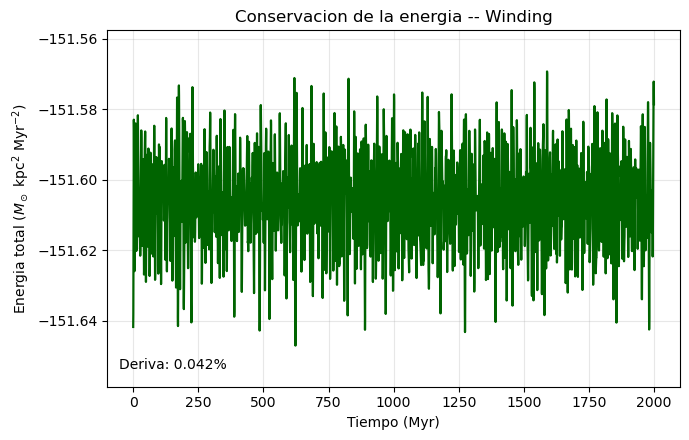

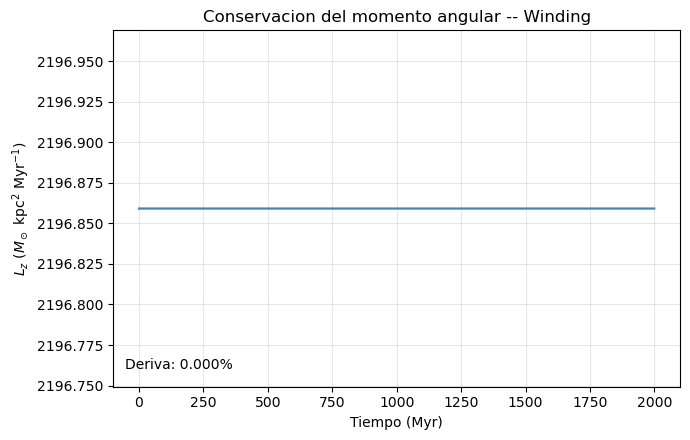

Deriva de energia: 0.042%  |  Deriva de L_z: 0.000%


In [4]:
# ==========================================
# CONSERVACION DE ENERGIA Y MOMENTO ANGULAR -- WINDING
# Dos figuras separadas (energia y momento angular). Mismo tamano de figura y de
# fuente que las figuras del modo m=2, para que los ejes se vean igual en el informe.
# ==========================================
E_w = np.loadtxt("energia_winding.txt")
L_w = np.loadtxt("momento_winding.txt")
tiempo = np.arange(len(E_w)) * h_sim  # eje temporal en Myr

def ylim_ajustado(ax, datos, factor=1.3, piso=5e-5):
    """Ajusta el eje y al rango real de los datos (con margen) para no recortar la curva."""
    centro = 0.5 * (datos.max() + datos.min())
    semirango = max(0.5 * (datos.max() - datos.min()) * factor, abs(centro) * piso)
    ax.set_ylim(centro - semirango, centro + semirango)

# --- Energia total ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tiempo, E_w, color='darkgreen', linewidth=1.6)
ylim_ajustado(ax, E_w)
ax.set_xlabel("Tiempo (Myr)")
ax.set_ylabel(r"Energia total ($M_\odot$ kpc$^2$ Myr$^{-2}$)")
ax.set_title("Conservacion de la energia -- Winding")
ax.ticklabel_format(useOffset=False)
ax.grid(True, alpha=0.3)
drift_E = abs(E_w[-1] - E_w[0]) / abs(E_w[0]) * 100
ax.text(0.02, 0.05, f"Deriva: {drift_E:.3f}%", transform=ax.transAxes)
plt.tight_layout()
plt.savefig("Energia_Winding.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Momento angular ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tiempo, L_w, color='steelblue', linewidth=1.6)
ylim_ajustado(ax, L_w)
ax.set_xlabel("Tiempo (Myr)")
ax.set_ylabel(r"$L_z$ ($M_\odot$ kpc$^2$ Myr$^{-1}$)")
ax.set_title(r"Conservacion del momento angular -- Winding")
ax.ticklabel_format(useOffset=False)
ax.grid(True, alpha=0.3)
drift_L = abs(L_w[-1] - L_w[0]) / abs(L_w[0]) * 100
ax.text(0.02, 0.05, f"Deriva: {drift_L:.3f}%", transform=ax.transAxes)
plt.tight_layout()
plt.savefig("Momento_Winding.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Deriva de energia: {drift_E:.3f}%  |  Deriva de L_z: {drift_L:.3f}%")

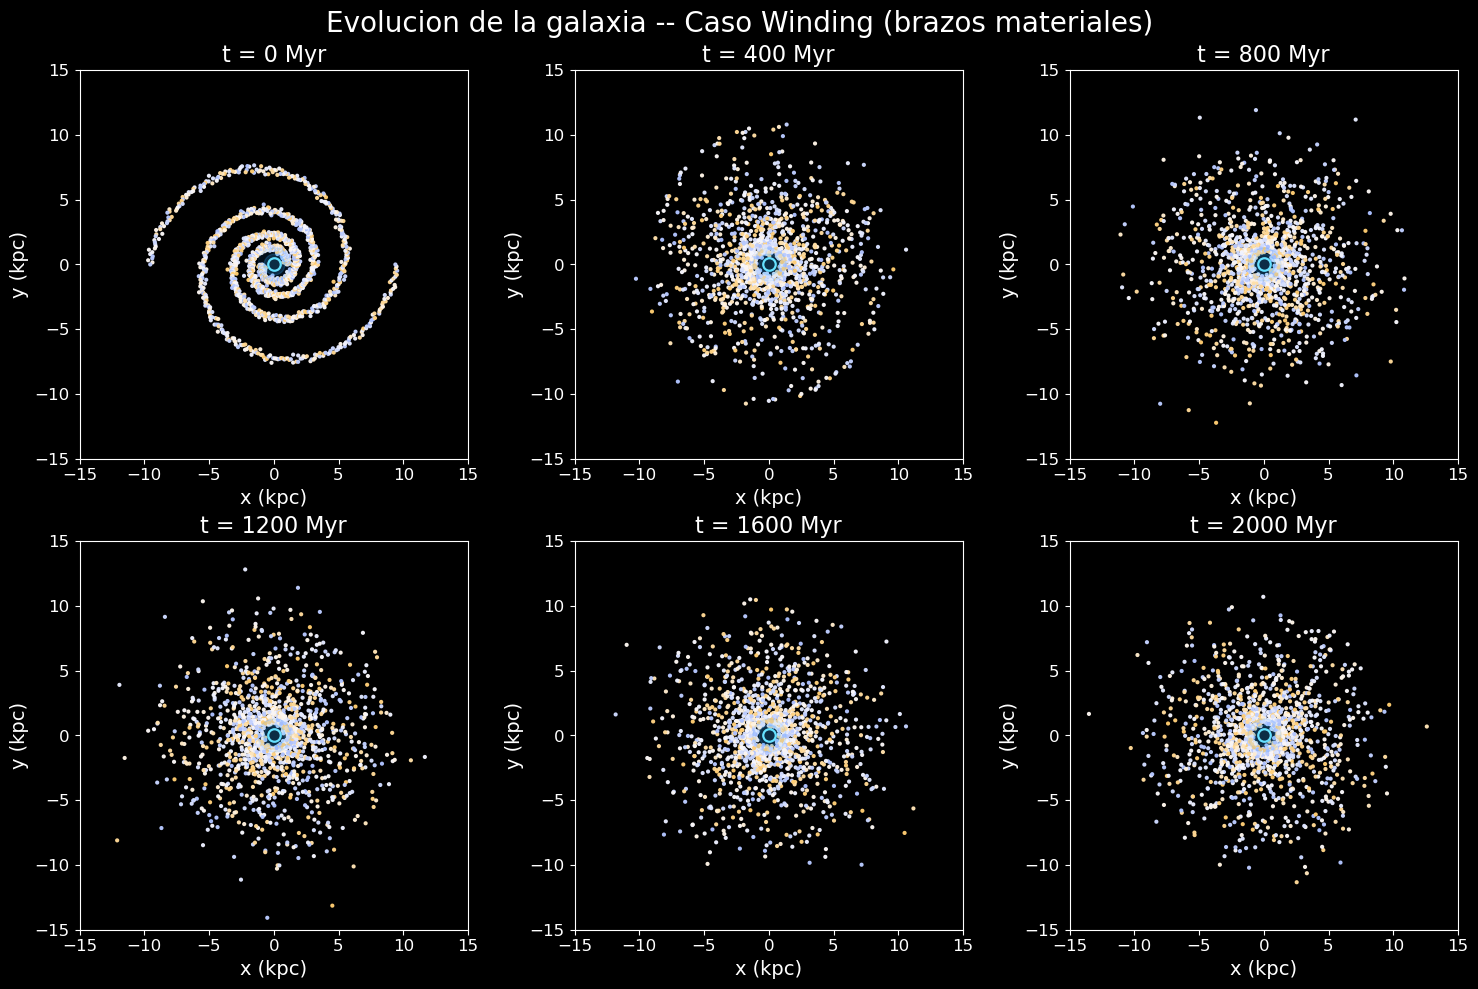

In [5]:
# ==========================================
# PANEL DE SNAPSHOTS -- WINDING (2x3)
# Representamos las estrellas individuales (no la densidad) porque lo relevante
# del winding es el DESTINO de las estrellas que forman los brazos materiales:
# se ve como se enrollan y dispersan. Las coloreamos segun su masa (mas masiva =
# mas azul/caliente) y dibujamos un nucleo central estilizado como agujero negro.
# Fuentes grandes y puntos de tamano s=4 para que se lea y se distingan los colores.
# ==========================================
pos_w = np.load("pos_winding.npy")  # shape: (n_frames, N+1, 2)

# Tamanos de fuente comunes a los paneles (legibles a DPI 300)
FS_SUP, FS_TIT, FS_LAB, FS_TICK = 20, 16, 14, 12

def colores_estelares(masas_estrellas):
    """
    Asigna a cada estrella un color RGB segun su masa, imitando la relacion
    masa-temperatura de la secuencia principal: estrellas masivas (tipos O-B-A)
    son azul-blancas; las de tipo solar (G) amarillo-blancas; las poco masivas
    (K-M) anaranjadas-rojizas.
    """
    m = np.asarray(masas_estrellas)
    anclas = [0.5,  0.8,  1.0,  1.3,  1.7,  2.0]   # M_sol
    R      = [1.00, 1.00, 1.00, 0.97, 0.79, 0.67]
    G      = [0.80, 0.87, 0.96, 0.97, 0.84, 0.75]
    B      = [0.44, 0.65, 0.91, 1.00, 1.00, 1.00]
    return np.column_stack([np.interp(m, anclas, R),
                            np.interp(m, anclas, G),
                            np.interp(m, anclas, B)])

def nucleo_agujero_negro(ax, x, y, escala=1.0):
    """Dibuja el nucleo central: halos azules difusos + anillo brillante con centro oscuro."""
    ax.plot(x, y, 'o', ms=24 * escala, color='#1e90ff', alpha=0.10)
    ax.plot(x, y, 'o', ms=15 * escala, color='#33aaff', alpha=0.20)
    ax.plot(x, y, 'o', ms=9 * escala, mfc='none', mec='#66e0ff', mew=1.6)

colores_w = colores_estelares(galaxia_w.masas[1:])  # masas[0] es la masa central

# Cada frame corresponde a freq_guardado * h_sim = 10 Myr
# t=0 -> frame 0 | t=400 Myr -> frame 40 | ... | t=2000 -> frame 200
tiempos_mostrar = [0, 400, 800, 1200, 1600, 2000]  # Myr
frames_mostrar  = [int(t // (freq_guardado * h_sim)) for t in tiempos_mostrar]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Evolucion de la galaxia -- Caso Winding (brazos materiales)",
             fontsize=FS_SUP, color='white')

for ax, frame, t in zip(axes.flat, frames_mostrar, tiempos_mostrar):
    ax.set_facecolor('black')
    ax.scatter(pos_w[frame, 1:, 0], pos_w[frame, 1:, 1],
               s=4.0, c=colores_w, alpha=0.95)
    nucleo_agujero_negro(ax, pos_w[frame, 0, 0], pos_w[frame, 0, 1])
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_aspect('equal')
    ax.set_title(f"t = {t} Myr", color='white', fontsize=FS_TIT)
    ax.set_xlabel("x (kpc)", color='white', fontsize=FS_LAB)
    ax.set_ylabel("y (kpc)", color='white', fontsize=FS_LAB)
    ax.tick_params(colors='white', labelsize=FS_TICK)
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

fig.patch.set_facecolor('black')
plt.tight_layout()
plt.savefig("Snapshots_Winding.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

In [6]:
# ==========================================
# ANIMACION GIF -- WINDING
# Estetica: estrellas coloreadas segun su masa (mas masiva = mas azul/caliente,
# menos masiva = mas roja/fria, como en la secuencia principal real) y un nucleo
# central estilizado como agujero negro (centro oscuro con anillo azul brillante).
# (colores_estelares se define en la celda de snapshots, mas arriba)
# ==========================================
pos_w    = np.load("pos_winding.npy")
n_frames = len(pos_w)

colores_w = colores_estelares(galaxia_w.masas[1:])  # masas[0] es la masa central

fig_anim, ax_anim = plt.subplots(figsize=(7, 7))
fig_anim.patch.set_facecolor('black')
ax_anim.set_facecolor('black')
ax_anim.set_xlim(-15, 15)
ax_anim.set_ylim(-15, 15)
ax_anim.set_aspect('equal')
ax_anim.set_xlabel("x (kpc)", color='white')
ax_anim.set_ylabel("y (kpc)", color='white')
ax_anim.tick_params(colors='white')
for spine in ax_anim.spines.values():
    spine.set_edgecolor('white')

scatter_w = ax_anim.scatter(pos_w[0, 1:, 0], pos_w[0, 1:, 1], s=1.8, c=colores_w, alpha=0.9)

# Nucleo estilo agujero negro: dos halos azules difusos + anillo brillante (mfc='none'
# deja ver el fondo negro en el centro, simulando la "sombra" del agujero negro)
glow2_w, = ax_anim.plot([], [], 'o', ms=34, color='#1e90ff', alpha=0.10)
glow1_w, = ax_anim.plot([], [], 'o', ms=22, color='#33aaff', alpha=0.20)
ring_w,  = ax_anim.plot([], [], 'o', ms=13, mfc='none', mec='#66e0ff', mew=2.2)
titulo_w = ax_anim.set_title("", color='white')

def init_w():
    for art in (glow2_w, glow1_w, ring_w):
        art.set_data([], [])
    return scatter_w, glow2_w, glow1_w, ring_w, titulo_w

def actualizar_w(i):
    scatter_w.set_offsets(pos_w[i, 1:, :])
    bx, by = pos_w[i, 0, 0], pos_w[i, 0, 1]
    for art in (glow2_w, glow1_w, ring_w):
        art.set_data([bx], [by])
    titulo_w.set_text(f"Winding  --  t = {i * freq_guardado * h_sim:.0f} Myr")
    return scatter_w, glow2_w, glow1_w, ring_w, titulo_w

ani_w = animation.FuncAnimation(fig_anim, actualizar_w, frames=n_frames,
                                  init_func=init_w, interval=60, blit=True)
print("Guardando Animacion_Winding.gif...")
ani_w.save("Animacion_Winding.gif", writer='pillow', fps=15)
print("Animacion Winding guardada.")
plt.close(fig_anim)

Guardando Animacion_Winding.gif...
Animacion Winding guardada.


---
# Paso 2: Teoría de Ondas de Densidad de Lin-Shu (1964)

Lin y Shu propusieron que los **brazos espirales no son estructuras materiales** sino **ondas de densidad** que recorren el disco galáctico. La clave está en la geometría de las órbitas estelares.

## Idea principal: órbitas elípticas correlacionadas

Si cada estrella sigue una órbita elíptica de semieje mayor $a$ con una orientación (argumento del periapsis) $\varphi_0 = k \cdot a$, entonces:

- Las órbitas interiores ($a$ pequeño) están giradas menos que las exteriores.
- Al ver la colección de todas las elipses juntas, sus apsidales (los puntos de máxima distancia al centro) forman una espiral.
- Las estrellas pasan **más tiempo** cerca del apoapsis (van más lentas, 2ª ley de Kepler), por lo que la densidad estelar es mayor allí.
- Ese exceso de densidad trazado por los apoapsis **dibuja la espiral**, aunque cada estrella individual entra y sale del brazo continuamente.

## Por qué el patrón persiste

En el caso Winding, la espiral desaparecía porque órbitas de distinto radio tienen distintos períodos (rotación diferencial). En Lin-Shu, no importa que los períodos sean distintos: la correlación $\varphi_0(a) = k \cdot a$ hace que, después de cualquier cantidad de órbitas, el patrón de densidad vuelva a ser similar. La espiral es una propiedad del **campo de velocidades** del disco, no de la identidad de las estrellas que la ocupan en cada momento.

In [7]:
# ==========================================
# INICIALIZACION Y SIMULACION -- LIN-SHU
# ==========================================
galaxia_ls = GalaxiaEspiral.Montar_Galaxia_LinShu(N_estrellas, h_sim)

datos_pos_ls = []
datos_E_ls   = []
datos_L_ls   = []

print("Iniciando simulacion Lin-Shu...")
for i in range(pasos_totales):
    if i % freq_guardado == 0:
        datos_pos_ls.append(galaxia_ls.r.copy())
    datos_E_ls.append(galaxia_ls.calcular_energia())
    datos_L_ls.append(galaxia_ls.calcular_momento_angular())

    galaxia_ls.actualizar_posicion()
    galaxia_ls.calcular_aceleracion()
    galaxia_ls.actualizar_velocidad()

    if i % 500 == 0:
        print(f"  Paso {i}/{pasos_totales}  ({i * h_sim:.0f} Myr)")

# Guardamos tambien el estado final (t = 2000 Myr) para tener el ultimo fotograma
datos_pos_ls.append(galaxia_ls.r.copy())

np.save("pos_linshu.npy", np.array(datos_pos_ls))
np.savetxt("energia_linshu.txt", datos_E_ls, fmt="%.12e")
np.savetxt("momento_linshu.txt", datos_L_ls, fmt="%.12e")
print(f"Simulacion Lin-Shu terminada. {len(datos_pos_ls)} fotogramas guardados.")

Iniciando simulacion Lin-Shu...
  Paso 0/4000  (0 Myr)
  Paso 500/4000  (250 Myr)
  Paso 1000/4000  (500 Myr)
  Paso 1500/4000  (750 Myr)
  Paso 2000/4000  (1000 Myr)
  Paso 2500/4000  (1250 Myr)
  Paso 3000/4000  (1500 Myr)
  Paso 3500/4000  (1750 Myr)
Simulacion Lin-Shu terminada. 201 fotogramas guardados.


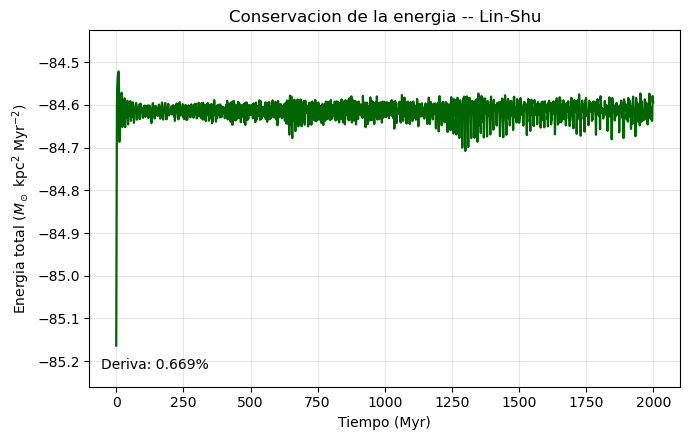

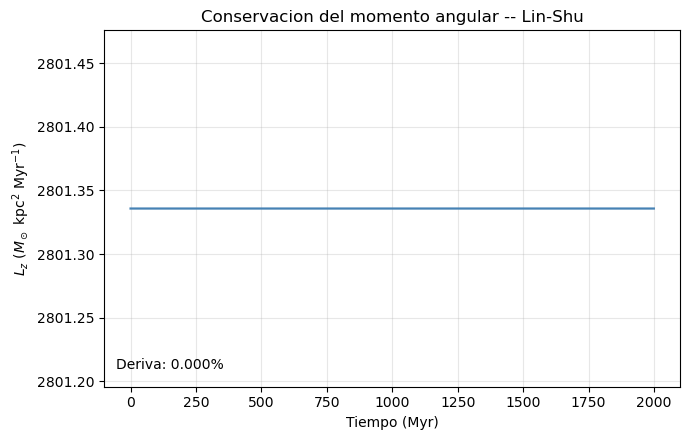

Deriva de energia: 0.669%  |  Deriva de L_z: 0.000%


In [8]:
# ==========================================
# CONSERVACION DE ENERGIA Y MOMENTO ANGULAR -- LIN-SHU
# Dos figuras separadas (energia y momento angular). Mismo tamano de figura y de
# fuente que las figuras del modo m=2, para que los ejes se vean igual en el informe.
# ==========================================
E_ls = np.loadtxt("energia_linshu.txt")
L_ls = np.loadtxt("momento_linshu.txt")
tiempo = np.arange(len(E_ls)) * h_sim

# --- Energia total ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tiempo, E_ls, color='darkgreen', linewidth=1.6)
ylim_ajustado(ax, E_ls)   # funcion definida en la celda de conservacion Winding
ax.set_xlabel("Tiempo (Myr)")
ax.set_ylabel(r"Energia total ($M_\odot$ kpc$^2$ Myr$^{-2}$)")
ax.set_title("Conservacion de la energia -- Lin-Shu")
ax.ticklabel_format(useOffset=False)
ax.grid(True, alpha=0.3)
drift_E_ls = abs(E_ls[-1] - E_ls[0]) / abs(E_ls[0]) * 100
ax.text(0.02, 0.05, f"Deriva: {drift_E_ls:.3f}%", transform=ax.transAxes)
plt.tight_layout()
plt.savefig("Energia_LinShu.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Momento angular ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tiempo, L_ls, color='steelblue', linewidth=1.6)
ylim_ajustado(ax, L_ls)
ax.set_xlabel("Tiempo (Myr)")
ax.set_ylabel(r"$L_z$ ($M_\odot$ kpc$^2$ Myr$^{-1}$)")
ax.set_title(r"Conservacion del momento angular -- Lin-Shu")
ax.ticklabel_format(useOffset=False)
ax.grid(True, alpha=0.3)
drift_L_ls = abs(L_ls[-1] - L_ls[0]) / abs(L_ls[0]) * 100
ax.text(0.02, 0.05, f"Deriva: {drift_L_ls:.3f}%", transform=ax.transAxes)
plt.tight_layout()
plt.savefig("Momento_LinShu.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Deriva de energia: {drift_E_ls:.3f}%  |  Deriva de L_z: {drift_L_ls:.3f}%")

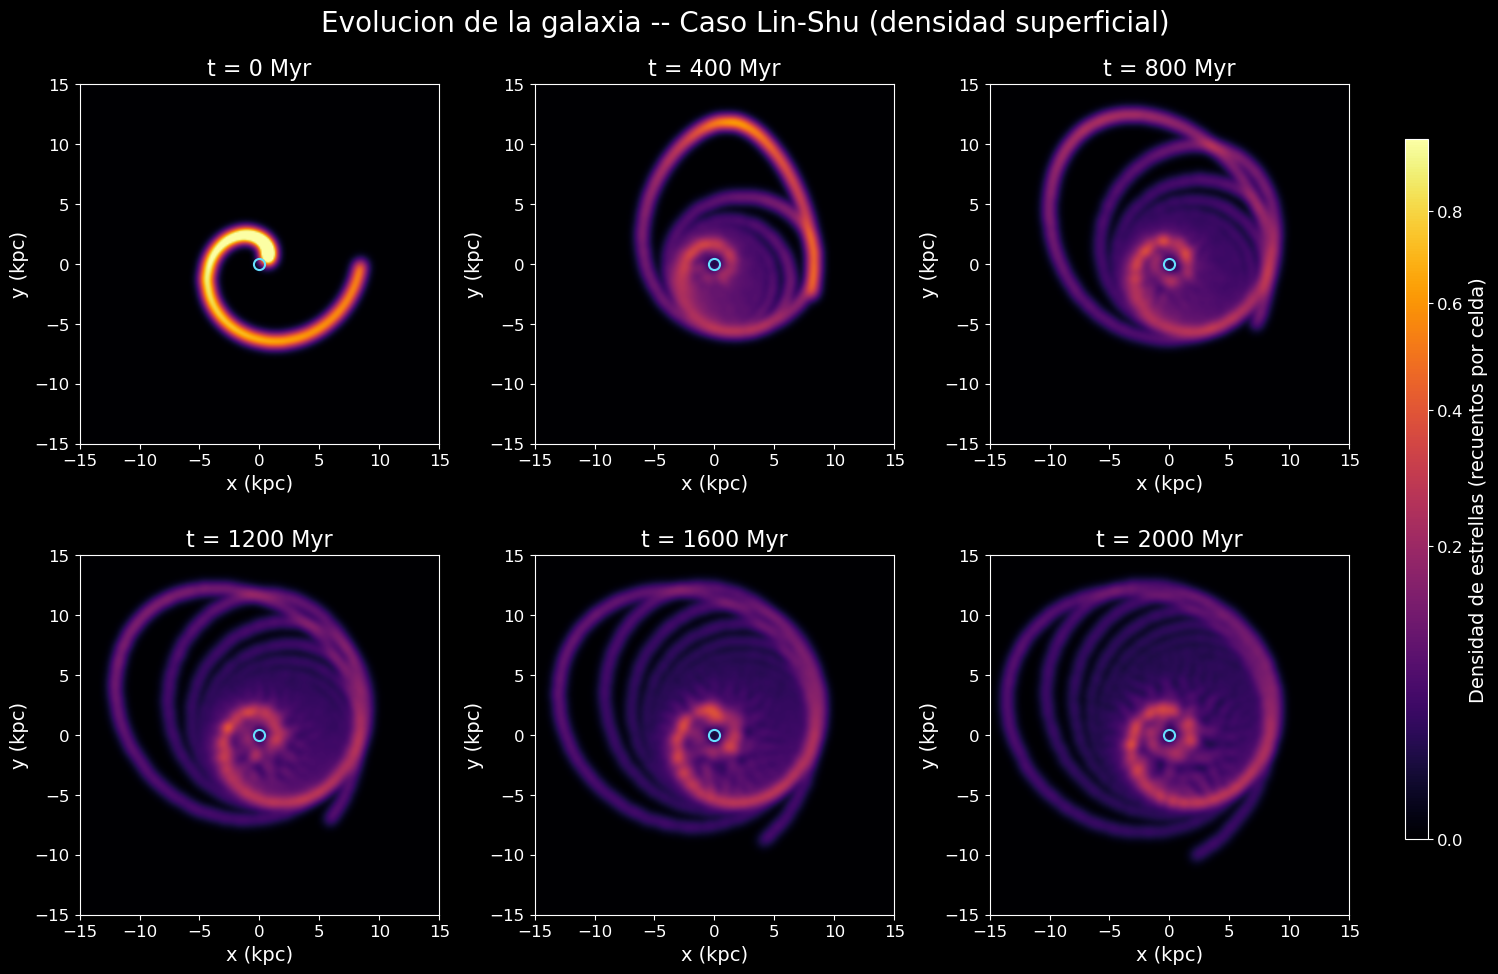

In [9]:
# ==========================================
# PANEL DE SNAPSHOTS -- LIN-SHU (2x3)  --  MAPA DE DENSIDAD
# En vez de puntos, representamos la densidad superficial de estrellas con un
# histograma 2D suavizado con un filtro gaussiano (colormap 'inferno'). Asi el
# exceso de densidad que forma el brazo espiral (la onda de densidad) RESALTA
# como zona brillante. Anadimos una COLORBAR comun (escala de densidad).
# ==========================================
pos_ls = np.load("pos_linshu.npy")

def mapa_densidad(ax, x, y, rng=15, bins=240, sigma=3.0, vmax=None):
    """
    Dibuja la densidad superficial de estrellas como un campo continuo:
    histograma 2D fino suavizado con un filtro gaussiano. Devuelve la imagen
    para poder anadirle una colorbar. vmax fija la escala (comun a los paneles).
    """
    H, _, _ = np.histogram2d(x, y, bins=bins, range=[[-rng, rng], [-rng, rng]])
    H = gaussian_filter(H, sigma=sigma)
    im = ax.imshow(H.T, origin='lower', extent=[-rng, rng, -rng, rng],
                   cmap='inferno', norm=mcolors.PowerNorm(0.55, vmin=0, vmax=vmax),
                   interpolation='bilinear', aspect='equal')
    return im, H

def estilo_colorbar(cbar):
    """Etiqueta y colores blancos para la colorbar sobre fondo negro."""
    cbar.set_label("Densidad de estrellas (recuentos por celda)",
                   color='white', fontsize=FS_LAB)
    cbar.ax.yaxis.set_tick_params(color='white', labelsize=FS_TICK)
    cbar.outline.set_edgecolor('white')
    plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

# vmax comun a los 6 paneles -> la colorbar significa lo mismo en todos
vmax_ls = 0.0
for frame in frames_mostrar:
    H, _, _ = np.histogram2d(pos_ls[frame, 1:, 0], pos_ls[frame, 1:, 1],
                             bins=240, range=[[-15, 15], [-15, 15]])
    H = gaussian_filter(H, sigma=3.0)
    vmax_ls = max(vmax_ls, np.percentile(H, 99.5))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Evolucion de la galaxia -- Caso Lin-Shu (densidad superficial)",
             fontsize=FS_SUP, color='white')

im = None
for ax, frame, t in zip(axes.flat, frames_mostrar, tiempos_mostrar):
    ax.set_facecolor('black')
    im, _ = mapa_densidad(ax, pos_ls[frame, 1:, 0], pos_ls[frame, 1:, 1], vmax=vmax_ls)
    # Nucleo: anillo azul que deja ver el centro oscuro
    ax.plot(pos_ls[frame, 0, 0], pos_ls[frame, 0, 1],
            'o', mfc='none', mec='#66e0ff', mew=1.5, markersize=8)
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_title(f"t = {t} Myr", color='white', fontsize=FS_TIT)
    ax.set_xlabel("x (kpc)", color='white', fontsize=FS_LAB)
    ax.set_ylabel("y (kpc)", color='white', fontsize=FS_LAB)
    ax.tick_params(colors='white', labelsize=FS_TICK)
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

fig.patch.set_facecolor('black')
plt.tight_layout(rect=[0, 0, 0.92, 1])
cax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
estilo_colorbar(fig.colorbar(im, cax=cax))
plt.savefig("Snapshots_LinShu.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

In [10]:
# ==========================================
# ANIMACION GIF -- LIN-SHU
# Misma estetica que la animacion Winding: estrellas coloreadas por masa y
# nucleo central estilizado como agujero negro.
# ==========================================
pos_ls   = np.load("pos_linshu.npy")
n_frames = len(pos_ls)

colores_ls = colores_estelares(galaxia_ls.masas[1:])  # reutiliza la funcion de la celda de snapshots Winding

fig_anim2, ax_anim2 = plt.subplots(figsize=(7, 7))
fig_anim2.patch.set_facecolor('black')
ax_anim2.set_facecolor('black')
ax_anim2.set_xlim(-15, 15)
ax_anim2.set_ylim(-15, 15)
ax_anim2.set_aspect('equal')
ax_anim2.set_xlabel("x (kpc)", color='white')
ax_anim2.set_ylabel("y (kpc)", color='white')
ax_anim2.tick_params(colors='white')
for spine in ax_anim2.spines.values():
    spine.set_edgecolor('white')

scatter_ls = ax_anim2.scatter(pos_ls[0, 1:, 0], pos_ls[0, 1:, 1], s=1.8, c=colores_ls, alpha=0.9)

glow2_ls, = ax_anim2.plot([], [], 'o', ms=34, color='#1e90ff', alpha=0.10)
glow1_ls, = ax_anim2.plot([], [], 'o', ms=22, color='#33aaff', alpha=0.20)
ring_ls,  = ax_anim2.plot([], [], 'o', ms=13, mfc='none', mec='#66e0ff', mew=2.2)
titulo_ls = ax_anim2.set_title("", color='white')

def init_ls():
    for art in (glow2_ls, glow1_ls, ring_ls):
        art.set_data([], [])
    return scatter_ls, glow2_ls, glow1_ls, ring_ls, titulo_ls

def actualizar_ls(i):
    scatter_ls.set_offsets(pos_ls[i, 1:, :])
    bx, by = pos_ls[i, 0, 0], pos_ls[i, 0, 1]
    for art in (glow2_ls, glow1_ls, ring_ls):
        art.set_data([bx], [by])
    titulo_ls.set_text(f"Lin-Shu  --  t = {i * freq_guardado * h_sim:.0f} Myr")
    return scatter_ls, glow2_ls, glow1_ls, ring_ls, titulo_ls

ani_ls = animation.FuncAnimation(fig_anim2, actualizar_ls, frames=n_frames,
                                   init_func=init_ls, interval=60, blit=True)
print("Guardando Animacion_LinShu.gif...")
ani_ls.save("Animacion_LinShu.gif", writer='pillow', fps=15)
print("Animacion Lin-Shu guardada.")
plt.close(fig_anim2)

Guardando Animacion_LinShu.gif...
Animacion Lin-Shu guardada.


Estrella 'solar': indice 955, semieje a = 8.00 kpc
Periodo orbital simulado:  223.5 Myr
Periodo real del Sol:      230.0 Myr
Error relativo:            2.8%


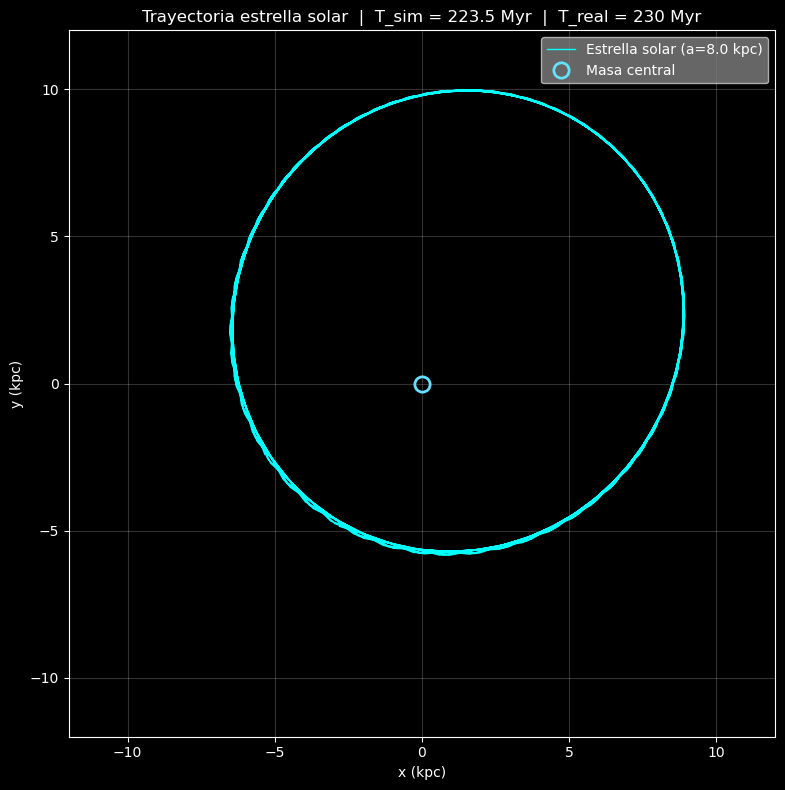

In [11]:
# ==========================================
# PERIODO ORBITAL DEL SOL (CASO LIN-SHU)
# Metodo robusto: en una orbita kepleriana el angulo polar respecto al foco
# (la masa central) avanza exactamente 2*pi en un periodo radial. Desenrollamos
# theta(t) = atan2(y, x) y buscamos el instante en que theta - theta_0 = 2*pi.
# Es mas fiable que detectar cruces Y=0, porque la orbita arranca en el periapsis
# girado un angulo phi_0 = k*a (no esta alineada con los ejes).
# ==========================================
pos_ls = np.load("pos_linshu.npy")  # shape: (n_frames, N+1, 2)
n_frames = len(pos_ls)
dt_frame = freq_guardado * h_sim     # tiempo entre fotogramas guardados (Myr)

# Buscamos la estrella cuyo semieje sea mas cercano a R_SOL = 8.0 kpc
semiejes_ls = np.linspace(1.0, 12.0, N_estrellas)
idx_sol     = np.argmin(np.abs(semiejes_ls - R_SOL)) + 1  # +1 porque el indice 0 es la masa central
a_sol       = semiejes_ls[idx_sol - 1]
print(f"Estrella 'solar': indice {idx_sol}, semieje a = {a_sol:.2f} kpc")

# Trayectoria de esa estrella (respecto a la masa central, que esta en el origen)
x_sol = pos_ls[:, idx_sol, 0] - pos_ls[:, 0, 0]
y_sol = pos_ls[:, idx_sol, 1] - pos_ls[:, 0, 1]

# Angulo polar desenrollado y tiempo
theta     = np.unwrap(np.arctan2(y_sol, x_sol))
theta_rel = theta - theta[0]            # arranca en 0, crece de forma monotona (orbita prograda)
times     = np.arange(n_frames) * dt_frame

# Si la orbita es retrograda, theta_rel decrece: trabajamos con su valor absoluto
if theta_rel[-1] < 0:
    theta_rel = -theta_rel

if theta_rel[-1] >= 2.0 * np.pi:
    # Interpolacion lineal: instante en que theta_rel alcanza 2*pi -> un periodo completo
    T_simulado = np.interp(2.0 * np.pi, theta_rel, times)
    error = abs(T_simulado - T_SOL_real) / T_SOL_real * 100
    print(f"Periodo orbital simulado:  {T_simulado:.1f} Myr")
    print(f"Periodo real del Sol:      {T_SOL_real:.1f} Myr")
    print(f"Error relativo:            {error:.1f}%")
else:
    print("La estrella solar no completo una orbita. Aumentar pasos_totales.")
    T_simulado = None

# Graficamos la trayectoria de la estrella solar
if T_simulado is not None:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('black')
    ax.plot(x_sol, y_sol, '-', color='cyan', linewidth=1.0,
            label=f'Estrella solar (a={a_sol:.1f} kpc)')
    ax.plot(0, 0, 'o', mfc='none', mec='#66e0ff', mew=2.0, markersize=11, label='Masa central')
    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.set_aspect('equal')
    ax.set_xlabel("x (kpc)", color='white')
    ax.set_ylabel("y (kpc)", color='white')
    ax.set_title(f"Trayectoria estrella solar  |  T_sim = {T_simulado:.1f} Myr  |  T_real = {T_SOL_real:.0f} Myr",
                 color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.legend(facecolor='gray', labelcolor='white')
    ax.grid(True, alpha=0.2, color='white')
    fig.patch.set_facecolor('black')
    plt.tight_layout()
    plt.savefig("Periodo_Solar.png", dpi=300, bbox_inches='tight', facecolor='black')
    plt.show()

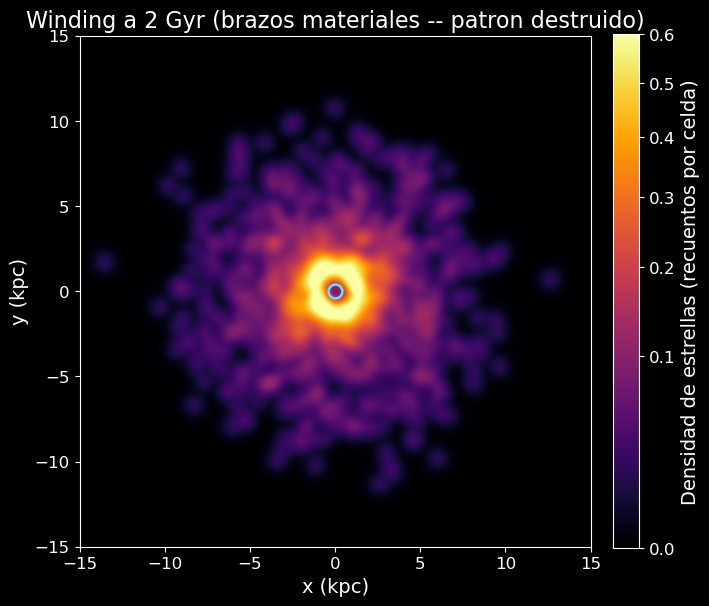

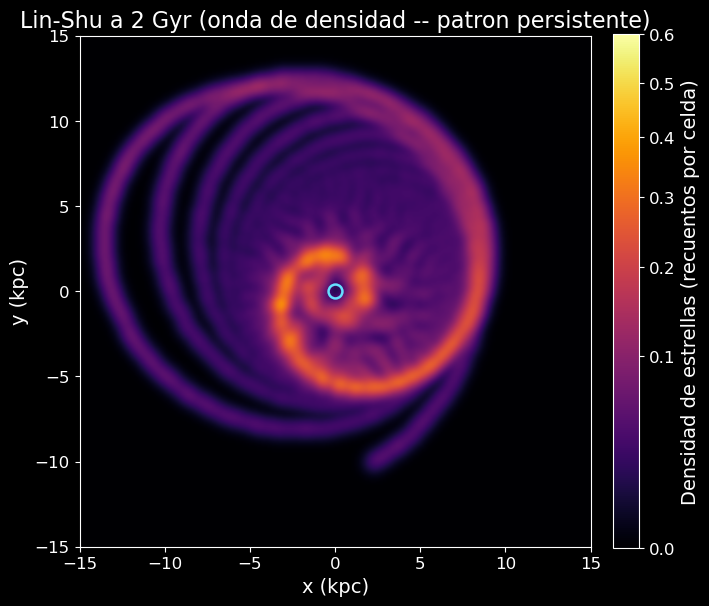

In [12]:
# ==========================================
# COMPARACION WINDING vs LIN-SHU a t = 2 Gyr  --  MAPA DE DENSIDAD
# Dos figuras separadas (una por caso) para que se lean bien en el informe.
# Misma escala de densidad (vmax comun) en las dos para poder compararlas: el
# winding queda como un disco liso y Lin-Shu mantiene un brazo brillante.
# ==========================================
pos_w  = np.load("pos_winding.npy")
pos_ls = np.load("pos_linshu.npy")

# vmax comun a los dos casos para que los colores sean comparables
vmax_cmp = 0.0
for pos in [pos_w, pos_ls]:
    H, _, _ = np.histogram2d(pos[-1, 1:, 0], pos[-1, 1:, 1],
                             bins=240, range=[[-15, 15], [-15, 15]])
    H = gaussian_filter(H, sigma=3.0)
    vmax_cmp = max(vmax_cmp, np.percentile(H, 99.5))

def figura_comparacion(pos, titulo, fichero):
    """Dibuja el mapa de densidad final de un caso y lo guarda en su propio PNG."""
    fig, ax = plt.subplots(figsize=(7, 6.2))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    im, _ = mapa_densidad(ax, pos[-1, 1:, 0], pos[-1, 1:, 1], vmax=vmax_cmp)
    ax.plot(pos[-1, 0, 0], pos[-1, 0, 1],
            'o', mfc='none', mec='#66e0ff', mew=1.8, markersize=10)
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_title(titulo, color='white', fontsize=FS_TIT)
    ax.set_xlabel("x (kpc)", color='white', fontsize=FS_LAB)
    ax.set_ylabel("y (kpc)", color='white', fontsize=FS_LAB)
    ax.tick_params(colors='white', labelsize=FS_TICK)
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    estilo_colorbar(fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04))
    plt.tight_layout()
    plt.savefig(fichero, dpi=300, bbox_inches='tight', facecolor='black')
    plt.show()

figura_comparacion(pos_w,  "Winding a 2 Gyr (brazos materiales -- patron destruido)",
                   "Comparacion_Winding.png")
figura_comparacion(pos_ls, "Lin-Shu a 2 Gyr (onda de densidad -- patron persistente)",
                   "Comparacion_LinShu.png")


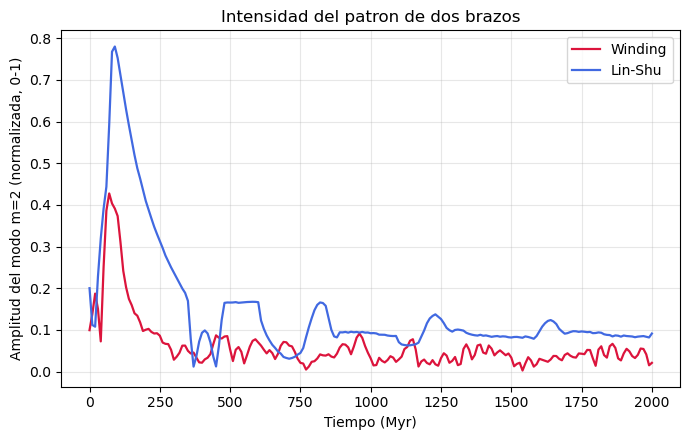

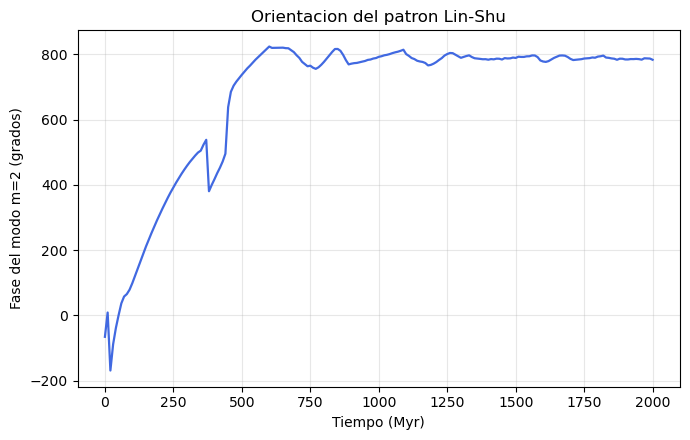

Winding: amplitud m=2  0.10 -> 0.02  (el patron se destruye)
Lin-Shu: amplitud m=2  0.20 -> 0.09  (el patron persiste)
Lin-Shu: la fase se estabiliza tras el transitorio inicial (patron anclado en el espacio)


In [13]:
# ==========================================
# ANALISIS CUANTITATIVO: intensidad del patron espiral (modo m=2)
# El modo azimutal m=2 mide la intensidad (amplitud) y la orientacion (fase) del
# patron de dos brazos, ponderado por el radio. Dibujamos amplitud y orientacion
# en DOS figuras separadas para que se lean bien en el informe.
# ==========================================
pos_w  = np.load("pos_winding.npy")
pos_ls = np.load("pos_linshu.npy")
tiempos = np.arange(len(pos_ls)) * (freq_guardado * h_sim)

def modo_m2(pos, r_min=3.0, r_max=11.0):
    """
    Amplitud y fase del modo azimutal m=2 de la densidad, ponderado por radio y
    normalizado (dividido por la suma de radios) para que sea adimensional, de 0 a 1,
    en el anillo [r_min, r_max] kpc. Una amplitud alta indica un patron de dos
    brazos intenso; una fase estable indica un patron anclado en el espacio.
    """
    amp = []
    fase = []
    for f in range(len(pos)):
        x = pos[f, 1:, 0] - pos[f, 0, 0]
        y = pos[f, 1:, 1] - pos[f, 0, 1]
        r = np.hypot(x, y)
        th = np.arctan2(y, x)
        sel = (r > r_min) & (r < r_max)
        z = np.sum(r[sel] * np.exp(2j * th[sel])) / np.sum(r[sel])  # normalizado por la suma de radios (adimensional)
        amp.append(abs(z))
        fase.append(np.angle(z))
    return np.array(amp), np.degrees(np.unwrap(fase))

amp_w, _        = modo_m2(pos_w)
amp_ls, fase_ls = modo_m2(pos_ls)

# --- Amplitud: intensidad del patron de dos brazos ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tiempos, amp_w,  color='crimson',   linewidth=1.6, label='Winding')
ax.plot(tiempos, amp_ls, color='royalblue', linewidth=1.6, label='Lin-Shu')
ax.set_xlabel("Tiempo (Myr)")
ax.set_ylabel("Amplitud del modo m=2 (normalizada, 0-1)")
ax.set_title("Intensidad del patron de dos brazos")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Modo_A2.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Fase: orientacion del patron (solo tiene sentido en Lin-Shu) ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tiempos, fase_ls, color='royalblue', linewidth=1.6)
ax.set_xlabel("Tiempo (Myr)")
ax.set_ylabel("Fase del modo m=2 (grados)")
ax.set_title("Orientacion del patron Lin-Shu")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Modo_Orientacion.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Winding: amplitud m=2  {amp_w[0]:.2f} -> {amp_w[-1]:.2f}  (el patron se destruye)")
print(f"Lin-Shu: amplitud m=2  {amp_ls[0]:.2f} -> {amp_ls[-1]:.2f}  (el patron persiste)")
print("Lin-Shu: la fase se estabiliza tras el transitorio inicial (patron anclado en el espacio)")
